In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.ndimage import gaussian_filter1d

In [5]:
sm=1

In [13]:
# Load the data
df = pd.read_csv(
    './for_deg/fork_deg_findl_3and_5hrs/2024_HCT_late.mat.gz',
    compression='gzip', sep='\t', skiprows=[0], header=None
)
df = df.fillna(0.0)
df = df.drop([0, 1, 2, 3, 4, 5], axis=1)
ctcf_array = df.to_numpy()
df 

,6,7,8,9,10,11,12,13,14,15,...,1596,1597,1598,1599,1600,1601,1602,1603,1604,1605
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.016784
1,0.000000,0.000000,0.008401,0.024687,0.000000,0.000000,0.000000,0.000000,0.000000,0.009283,...,0.000000,0.000000,0.000000,0.000000,0.015926,0.086006,0.020537,0.000000,0.000000,0.000000
2,0.097714,0.071013,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.048082,0.142222,0.197857,0.140570,0.064397,0.118440
3,0.046250,0.071688,0.009910,0.000000,0.037907,0.023002,0.008005,0.033632,0.028246,0.017982,...,0.000000,0.025653,0.055440,0.001636,0.000000,0.000000,0.017683,0.000000,0.000000,0.000000
4,0.000884,0.005280,0.019505,0.017030,0.002470,0.000000,0.000000,0.002681,0.029867,0.026701,...,0.000000,0.000000,0.000000,0.004414,0.039623,0.022817,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47886,0.000000,0.021499,0.041270,0.021635,0.019384,0.046369,0.028539,0.000000,0.028923,0.001013,...,0.000000,0.005165,0.005578,0.000000,0.000000,0.000000,0.000000,0.000000,0.000063,0.014909
47887,0.000000,0.000000,0.040861,0.037967,0.057682,0.041690,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.026070,0.037408,0.024586,0.012339,0.025161,0.030740,0.000000
47888,0.125945,0.106257,0.035478,0.000000,0.000000,0.000000,0.023943,0.002839,0.000000,0.050699,...,0.000571,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
47889,0.033091,0.030731,0.014263,0.002415,0.000000,0.000000,0.000000,0.011863,0.014595,0.001418,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [14]:
# ========================
# USER / HARDCODED SETUP
# ========================
# Order here MUST match the column layout in ctcf_array along axis=1
var_names = [
    "WT_HU",
    "G9ai",
    "CTCFkd",
    "DKD"
]

# Number of splits = number of names
n_splits = len(var_names)

# ========================
# SPLIT ONCE
# ========================
split_arrays = np.split(ctcf_array, n_splits, axis=1)

# Map each name -> its slice
arrays = {name: arr for name, arr in zip(var_names, split_arrays)}

# ========================
# STATS CONTAINERS
# ========================
means = {}
stds_early = {}
means_early = {}

# ========================
# LOOP OVER ALL NAMED SLICES
# ========================
for name in var_names:
    # skip x (coordinate axis)
    if name == "x":
        continue

    arr = arrays[name]              # shape (N, M)
    mask = arr != 0                 # ignore zeros
    count = np.sum(mask, axis=0)    # per-column nonzero counts

    mean = np.zeros(arr.shape[1], dtype=float)
    std = np.zeros(arr.shape[1], dtype=float)

    valid = count > 0               # avoid division by zero

    # mean over non-zero entries
    mean[valid] = (
        np.sum(arr[:, valid] * mask[:, valid], axis=0) / count[valid]
    )

    # std over non-zero entries
    std[valid] = np.sqrt(
        np.sum(
            mask[:, valid] * (arr[:, valid] - mean[valid]) ** 2,
            axis=0
        ) / count[valid]
    )

    means[name] = mean
    stds_early[name] = std
    means_early[name] = gaussian_filter1d(mean, sigma=sm)


shift = np.min(means_early['G9ai']) - 0.01
means_early['WT_HU'] = np.array(means_early['WT_HU']) - shift

/var/folders/c0/r1z251qj2mvczjs_mvjhpzqr0000gn/T/ipykernel_12596/1829317013.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


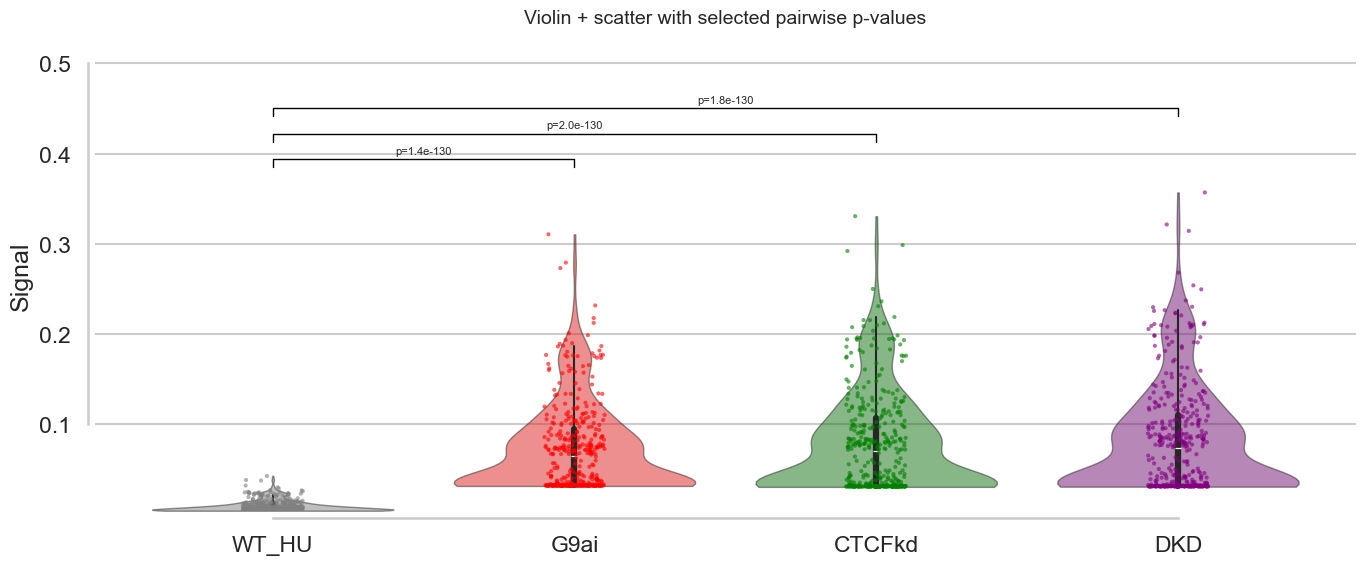

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# 1) Data dict
# ------------------------------------------------------------
data = means_early

# WT baseline
WT_KEY = "WT_HU"

# ------------------------------------------------------------
# 2) Conditions to plot (UT and WT_BrdU_FT removed)
# ------------------------------------------------------------
order = [
    "WT_HU", 
    "G9ai", 
    "CTCFkd", 
    "DKD", 
]

# ------------------------------------------------------------
# 3) Tidy DataFrame
# ------------------------------------------------------------
rows = []
for cond in order:
    arr = data[cond]
    for v in arr:
        rows.append({"Condition": cond, "Value": v})

df = pd.DataFrame(rows)
df["Condition"] = pd.Categorical(df["Condition"], categories=order, ordered=True)

# ------------------------------------------------------------
# 4) Palette: WT/G9ai/CTCFkd/DKD with lighter mirin shades
# ------------------------------------------------------------
cond_palette = {
    "WT_HU":      "grey",
    "G9ai":       "red",
    "CTCFkd":       "green",
    "DKD":       "purple"
}

# ------------------------------------------------------------
# 5) Violin + scatter
# ------------------------------------------------------------
sns.set(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(14, 6))

sns.violinplot(
    data=df,
    x="Condition", y="Value",
    order=order,
    palette=cond_palette,
    inner="box",
    cut=0,
    linewidth=1.0,
    ax=ax,
    alpha=0.5
)

sns.stripplot(
    data=df,
    x="Condition", y="Value",
    order=order,
    hue="Condition",
    hue_order=order,
    palette=cond_palette,
    dodge=False,
    size=3,
    alpha=0.6,
    legend=False,
    ax=ax
)

# ------------------------------------------------------------
# 6) Define specific comparison pairs
# ------------------------------------------------------------
pairs = []

# WT vs {G9ai, CTCFkd, DKD, WT_mirin}
pairs.extend([
    (WT_KEY, "G9ai"),
    (WT_KEY, "CTCFkd"),
    (WT_KEY, "DKD")
])

# WT_mirin vs {G9ai_mirin, CTCFkd_mirin, DKD_mirin}
# pairs.extend([
#     ("WT_mirin"),
#     ("WT_mirin", "CTCFkd_mirin"),
#     ("WT_mirin", "DKD_mirin"),
# ])

# IR vs {WT, WT_mirin}
# pairs.extend([
#     ("IR", WT_KEY),
#     ("IR", "WT_mirin"),
# ])

# ------------------------------------------------------------
# 7) Compute and plot p-values (Mann–Whitney U)
# ------------------------------------------------------------
y_min = df["Value"].min()
y_max = df["Value"].max()
step = (y_max - y_min) * 0.08   # vertical spacing between brackets
top = y_max

for i, (c1, c2) in enumerate(pairs):
    x1 = order.index(c1)
    x2 = order.index(c2)

    g1 = df.loc[df["Condition"] == c1, "Value"]
    g2 = df.loc[df["Condition"] == c2, "Value"]

    stat, pval = mannwhitneyu(g1, g2, alternative="two-sided")

    y = top + step * (i + 1)
    y_top = y + 0.3 * step
    y_text = y + 0.45 * step

    # bracket
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.0,
        c="black"
    )

    # p-value text
    ax.text(
        (x1 + x2) / 2,
        y_text,
        f"p={pval:.1e}",
        ha="center",
        va="bottom",
        fontsize=8
    )

ax.set_ylim(y_min, top + step * (len(pairs) + 3))

# ------------------------------------------------------------
# 8) Cosmetics
# ------------------------------------------------------------
ax.set_title("Violin + scatter with selected pairwise p-values", fontsize=14, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Signal")
plt.xticks(rotation=90)
sns.despine(offset=5, trim=True)
plt.tight_layout()
plt.savefig("./fig_1/hct_3hrs_lessthan2_violin.svg", format="svg", dpi=1200)
plt.show()


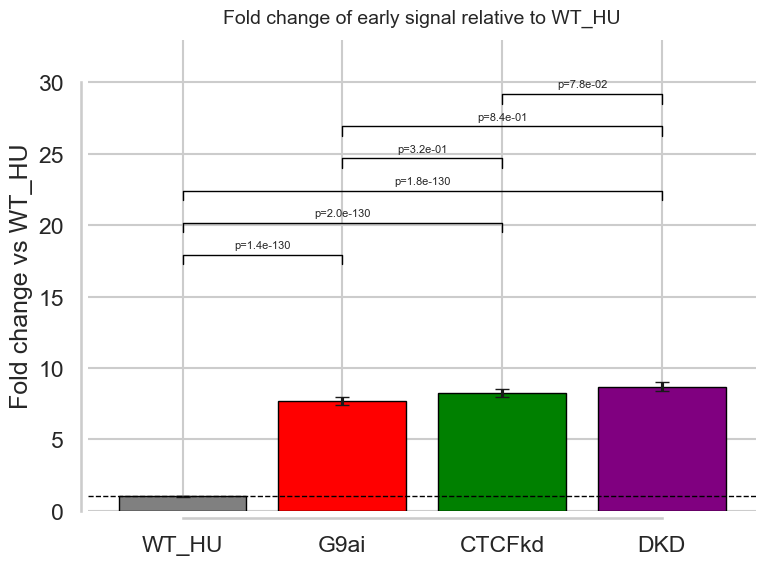

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from itertools import combinations

# ------------------------------------------------------------
# 1) Data dict
# ------------------------------------------------------------
# means_early must be a dict-like: key -> 1D array/list of values
data = means_early

# WT baseline key
WT_KEY = "WT_HU"

# conditions to use
order = [
    "WT_HU",
    "G9ai",
    "CTCFkd",
    "DKD",
]

# ------------------------------------------------------------
# 2) Tidy DataFrame with raw values
# ------------------------------------------------------------
rows = []
for cond in order:
    vals = np.asarray(data[cond], dtype=float)
    for v in vals:
        rows.append({"Condition": cond, "Value": v})

df = pd.DataFrame(rows)
df["Condition"] = pd.Categorical(df["Condition"], categories=order, ordered=True)

# ------------------------------------------------------------
# 3) Palette
# ------------------------------------------------------------
cond_palette = {
    "WT_HU":  "grey",
    "G9ai":   "red",
    "CTCFkd": "green",
    "DKD":    "purple",
}

# ------------------------------------------------------------
# 4) Compute fold change vs WT_HU (per condition)
# ------------------------------------------------------------
wt_vals = np.asarray(data[WT_KEY], dtype=float)
wt_mean = wt_vals.mean()

plot_conds = order  # same as order, but kept explicit

fc_means = []
fc_sems  = []

for cond in plot_conds:
    vals = np.asarray(data[cond], dtype=float)
    # fold change per replicate
    fc_vals = vals / wt_mean

    fc_means.append(fc_vals.mean())
    if len(fc_vals) > 1:
        fc_sems.append(fc_vals.std(ddof=1) / np.sqrt(len(fc_vals)))
    else:
        fc_sems.append(0.0)

fc_means = np.array(fc_means)
fc_sems  = np.array(fc_sems)

# ------------------------------------------------------------
# 5) Bar plot with error bars
# ------------------------------------------------------------
sns.set(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(plot_conds))

bars = ax.bar(
    x,
    fc_means,
    yerr=fc_sems,
    capsize=5,
    linewidth=1.0,
    edgecolor="black",
)

# color bars
for bar, cond in zip(bars, plot_conds):
    bar.set_facecolor(cond_palette[cond])

# baseline WT fold change = 1
ax.axhline(1.0, linestyle="--", linewidth=1.0, color="black")

ax.set_xticks(x)
ax.set_xticklabels(plot_conds, rotation=90)
ax.set_ylabel("Fold change vs WT_HU")
ax.set_xlabel("")
ax.set_title("Fold change of early signal relative to WT_HU", fontsize=14, pad=12)

# ------------------------------------------------------------
# 6) All pairwise p-values (Mann–Whitney) using raw values
# ------------------------------------------------------------
pairs = list(combinations(plot_conds, 2))  # all-vs-all

cond_to_x = {c: i for i, c in enumerate(plot_conds)}

# place brackets above tallest bar
y_max = 15
y_min = 0.0
step  = y_max * 0.15
top   = y_max

for i, (c1, c2) in enumerate(pairs):
    x1 = cond_to_x[c1]
    x2 = cond_to_x[c2]

    g1 = df.loc[df["Condition"] == c1, "Value"]
    g2 = df.loc[df["Condition"] == c2, "Value"]

    stat, pval = mannwhitneyu(g1, g2, alternative="two-sided")

    y = top + step * (i + 1)
    y_top = y + 0.3 * step
    y_text = y + 0.45 * step

    # bracket
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.0,
        c="black",
    )

    # p-value text
    ax.text(
        (x1 + x2) / 2,
        y_text,
        f"p={pval:.1e}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.set_ylim(y_min, top + step * (len(pairs) + 2))

sns.despine(offset=5, trim=True)
plt.tight_layout()
plt.savefig("./fig_1/hct_5hrs_lessthan2_foldchange_bar_allpairs.svg",
            format="svg", dpi=1200)
plt.show()


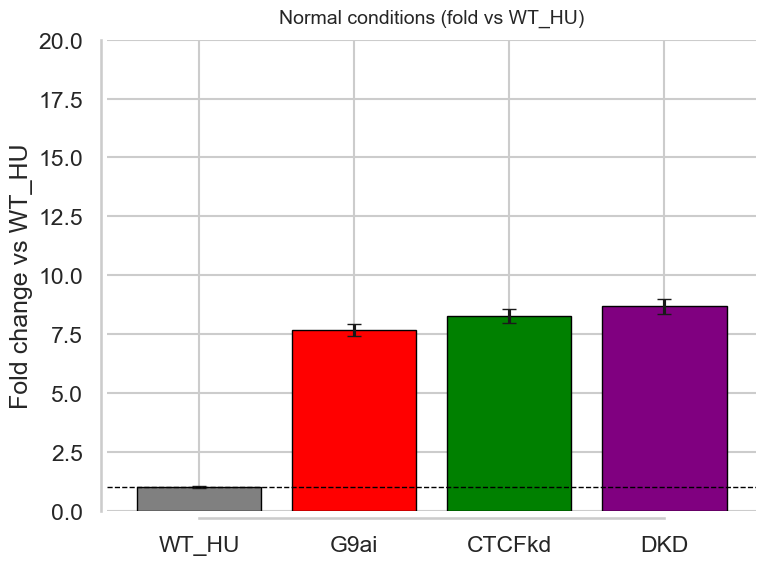

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from itertools import combinations

# ------------------------------------------------------------
# 1) Data dict
# ------------------------------------------------------------
# means_early must be a dict-like: key -> 1D array/list of values
data = means_early

# WT baseline key
WT_KEY = "WT_HU"

# conditions to use
order = [
    "WT_HU",
    "G9ai",
    "CTCFkd",
    "DKD",
]

# ------------------------------------------------------------
# 2) Tidy DataFrame with raw values
# ------------------------------------------------------------
rows = []
for cond in order:
    vals = np.asarray(data[cond], dtype=float)
    for v in vals:
        rows.append({"Condition": cond, "Value": v})

df = pd.DataFrame(rows)
df["Condition"] = pd.Categorical(df["Condition"], categories=order, ordered=True)

# ------------------------------------------------------------
# 3) Palette
# ------------------------------------------------------------
cond_palette = {
    "WT_HU":  "grey",
    "G9ai":   "red",
    "CTCFkd": "green",
    "DKD":    "purple",
}

# ------------------------------------------------------------
# 5) Helper: fold-change bar plot with p-values ABOVE 10
#    only for the conditions in `subset` (here: normal only)
# ------------------------------------------------------------
def make_fc_bar(ax, subset, title):
    """
    subset: list of condition names to show as bars
    title:  subplot title
    """
    # WT baseline mean
    wt_vals = np.asarray(data[WT_KEY], dtype=float)
    wt_mean = wt_vals.mean()

    # fold-change stats
    fc_means = []
    fc_sems  = []

    for cond in subset:
        vals = np.asarray(data[cond], dtype=float)
        fc_vals = vals / wt_mean  # per-replicate fold change

        fc_means.append(fc_vals.mean())
        if len(fc_vals) > 1:
            fc_sems.append(fc_vals.std(ddof=1) / np.sqrt(len(fc_vals)))
        else:
            fc_sems.append(0.0)

    fc_means = np.array(fc_means)
    fc_sems  = np.array(fc_sems)

    # bar plot
    x = np.arange(len(subset))

    bars = ax.bar(
        x,
        fc_means,
        yerr=fc_sems,
        capsize=5,
        linewidth=1.0,
        edgecolor="black",
    )

    for bar, cond in zip(bars, subset):
        bar.set_facecolor(cond_palette.get(cond, "black"))

    # baseline WT fold change = 1
    ax.axhline(1.0, linestyle="--", linewidth=1.0, color="black")

    ax.set_xticks(x)
    ax.set_xticklabels(subset, rotation=90)
    ax.set_ylabel("Fold change vs WT_HU")
    ax.set_xlabel("")
    ax.set_title(title, fontsize=14, pad=12)

    # # --- p-values: all pairwise within subset (normal only) ---
    # cond_to_x = {c: i for i, c in enumerate(subset)}
    # pairs = list(combinations(subset, 2))

    # axis:
    # - 0–10: bars
    # - >10: p-values, with fixed step between them
    y_min = 0.0
    y_max_plot = 20.0

    # pv_bottom = bar_max + 0.2    # first bracket starts above 10
    # step = 0.3                   # vertical distance between p-value rows

    # pv_top = pv_bottom + step * (len(pairs) + 1)
    # y_max_plot = pv_top + step   # small margin above last row

    # for i, (c1, c2) in enumerate(pairs):
    #     x1 = cond_to_x[c1]
    #     x2 = cond_to_x[c2]

    #     g1 = df.loc[df["Condition"] == c1, "Value"]
    #     g2 = df.loc[df["Condition"] == c2, "Value"]

    #     stat, pval = mannwhitneyu(g1, g2, alternative="two-sided")

    #     y = pv_bottom + step * (i + 1)
    #     y_top = y + step * 0.3
    #     y_text = y + step * 0.45

    #     # bracket
    #     ax.plot(
    #         [x1, x1, x2, x2],
    #         [y,  y_top, y_top, y],
    #         lw=1.0,
    #         c="black",
    #     )

    #     # p-value text
    #     ax.text(
    #         (x1 + x2) / 2,
    #         y_text,
    #         f"p={pval:.1e}",
    #         ha="center",
    #         va="bottom",
    #         fontsize=8,
    #     )

    # final axis: ticks only on bar region up to 10
    ax.set_ylim(y_min, y_max_plot)
    # ax.set_yticks([0, 2, 4, 6, 8, 10])

# ------------------------------------------------------------
# 6) Single subplot: NORMAL CONDITIONS ONLY
# ------------------------------------------------------------
sns.set(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(8, 6))

subset_normal = ["WT_HU", "G9ai", "CTCFkd", "DKD"]

make_fc_bar(ax, subset_normal, "Normal conditions (fold vs WT_HU)")

sns.despine(ax=ax, offset=5, trim=True)

plt.tight_layout()
plt.savefig("./fig_1/hct_5hrs_lessthan2_foldchange_bar_NOPVAL_20.svg",
            format="svg", dpi=1200)
plt.show()
